In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

#### Load cleaned data

In [5]:
df = pd.read_csv('data/f1_laps_clean.csv')

In [6]:
df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
       'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

#### Encode and standardize features

In [7]:
df.dtypes

Driver             object
Team               object
Year                int64
Race               object
Stint             float64
LapTime            object
LapNumber         float64
Position          float64
Compound           object
TyreLife          float64
FreshTyre            bool
TrackStatus         int64
AirTemp           float64
Humidity          float64
Pressure          float64
Rainfall             bool
TrackTemp         float64
WindDirection     float64
WindSpeed         float64
Speed_Mean        float64
Speed_Max         float64
Speed_Std         float64
RPM_Mean          float64
Throttle_Mean     float64
Throttle_Std      float64
Brake_Mean        float64
Gear_Mean         float64
Distance_Total    float64
DRS_active_pct    float64
LapsTilPit        float64
dtype: object

In [8]:
# Turn bool values into int
df['FreshTyre'] = df['FreshTyre'].astype(int)
df['Rainfall'] = df['Rainfall'].astype(int)

In [9]:
ordinal_cols = ['Stint', 'Position']  # leave as is
label = ['LapsTilPit']

categorical_cols = ['Driver', 'Team', 'Race', 'TrackStatus', 'Compound']

numerical_cols = ['LapTimeSeconds', 'LapNumber', 'TyreLife',
       'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std',
       'RPM_Mean', 'Brake_Mean', 'Gear_Mean', 'Distance_Total', 'DRS_active_pct']

In [10]:
df_encoded = df.copy()

In [11]:
# Apply cyclical encoding
df_encoded['WindDir_sin'] = np.sin(np.deg2rad(df_encoded['WindDirection']))
df_encoded['WindDir_cos'] = np.cos(np.deg2rad(df_encoded['WindDirection']))

df_encoded = df_encoded.drop(columns=['WindDirection'])

In [12]:
# Label encode
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le


In [13]:
df_encoded.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
       'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'RPM_Mean', 'Throttle_Mean',
       'Throttle_Std', 'Brake_Mean', 'Gear_Mean', 'Distance_Total',
       'DRS_active_pct', 'LapsTilPit', 'WindDir_sin', 'WindDir_cos'],
      dtype='object')

In [14]:
df_encoded.loc[0]

Driver                                28
Team                                  11
Year                                2022
Race                                   4
Stint                                1.0
LapTime           0 days 00:01:40.236000
LapNumber                            1.0
Position                             2.0
Compound                               3
TyreLife                             4.0
FreshTyre                              0
TrackStatus                            0
AirTemp                             23.9
Humidity                            25.0
Pressure                          1010.2
Rainfall                               0
TrackTemp                           29.1
WindSpeed                            0.5
Speed_Mean                    183.433962
Speed_Max                          286.0
Speed_Std                      66.059742
RPM_Mean                    10247.797844
Throttle_Mean                  61.336927
Throttle_Std                   43.993946
Brake_Mean      

In [15]:
# Convert LapTime to seconds
df_encoded['LapTimeSeconds'] = pd.to_timedelta(df_encoded['LapTime']).dt.total_seconds()
df_encoded = df_encoded.drop(columns=['LapTime'])

df_encoded['LapTimeSeconds']

0        100.236
1        101.006
2        108.826
3        104.270
4        101.555
          ...   
82196     79.675
82197     80.110
82198     79.899
82199     81.201
82200     79.978
Name: LapTimeSeconds, Length: 82201, dtype: float64

In [16]:
# Standardize numerical columns
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [17]:
df_encoded[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LapTimeSeconds,82201.0,1.174715e-16,1.000006,-0.701046,-0.294124,-0.055866,0.183963,67.107506
LapNumber,82201.0,3.457587e-17,1.000006,-1.617451,-0.851054,-0.029914,0.791225,2.597733
TyreLife,82201.0,-1.936249e-17,1.000006,-1.286066,-0.810355,-0.239501,0.521637,6.039890
AirTemp,82201.0,2.814476e-16,1.000006,-2.278857,-0.759499,0.020711,0.780390,2.710385
Humidity,82201.0,-3.595890e-17,1.000006,-2.823568,-0.709306,0.054178,0.700202,2.285899
Pressure,82201.0,1.241447e-15,1.000006,-3.978485,0.059582,0.403247,0.498710,0.647632
TrackTemp,82201.0,-5.788000e-16,1.000006,-2.277085,-0.663041,-0.005895,0.812656,2.553517
WindSpeed,82201.0,-1.369204e-16,1.000006,-1.601962,-0.647873,-0.214196,0.479687,5.857279
Speed_Mean,82201.0,5.393835e-16,1.000006,-7.288203,-0.464626,0.117173,0.699305,2.159354
Speed_Max,82201.0,1.372662e-16,1.000006,-15.984814,-0.460718,-0.046742,0.625969,3.109825


#### Split into train, val, and test sets

In [18]:
# Train, val, test split
train_df = df_encoded[df_encoded['Year'].isin([2022, 2023])]
val_df   = df_encoded[df_encoded['Year'] == 2024]
test_df  = df_encoded[df_encoded['Year'] == 2025]

In [19]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(47033, 31)
(26381, 31)
(8787, 31)


In [20]:
# Split sets into features and target
feature_cols = [col for col in train_df.columns if col not in ['LapsTilPit', 'Year']]

# Training set
X_train = train_df[feature_cols]
y_train = train_df['LapsTilPit']

# Validation set
X_val = val_df[feature_cols]
y_val = val_df['LapsTilPit']

# Test set
X_test = test_df[feature_cols]
y_test = test_df['LapsTilPit']

In [21]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(47033, 29)
(47033,)
(26381, 29)
(26381,)
(8787, 29)
(8787,)


#### Train XGBoost regression model

In [22]:
# Train XGBoost regressor
xgb_reg = XGBRegressor()
xgb_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

[0]	validation_0-rmse:10.26867
[1]	validation_0-rmse:9.72649
[2]	validation_0-rmse:9.38003
[3]	validation_0-rmse:9.16553
[4]	validation_0-rmse:9.13802
[5]	validation_0-rmse:9.02600
[6]	validation_0-rmse:8.99479
[7]	validation_0-rmse:9.00006
[8]	validation_0-rmse:8.98080
[9]	validation_0-rmse:9.00169
[10]	validation_0-rmse:8.99686
[11]	validation_0-rmse:8.95035
[12]	validation_0-rmse:8.95570
[13]	validation_0-rmse:8.96792
[14]	validation_0-rmse:9.00218
[15]	validation_0-rmse:9.03821
[16]	validation_0-rmse:9.03117
[17]	validation_0-rmse:9.03842
[18]	validation_0-rmse:9.05891
[19]	validation_0-rmse:9.06740
[20]	validation_0-rmse:9.06673
[21]	validation_0-rmse:9.05983
[22]	validation_0-rmse:9.10783
[23]	validation_0-rmse:9.11365
[24]	validation_0-rmse:9.10483
[25]	validation_0-rmse:9.09779
[26]	validation_0-rmse:9.10628
[27]	validation_0-rmse:9.08352
[28]	validation_0-rmse:9.09826
[29]	validation_0-rmse:9.06222
[30]	validation_0-rmse:9.06171
[31]	validation_0-rmse:9.05397
[32]	validation_0

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [23]:
# Predict
y_val_pred = xgb_reg.predict(X_val)
y_test_pred = xgb_reg.predict(X_test)

# Evaluate
print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred):.3f}")

Validation Results:
RMSE: 9.513
MAE:  6.894
R2:   0.276

Test Results:
RMSE: 9.196
MAE:  6.765
R2:   0.219


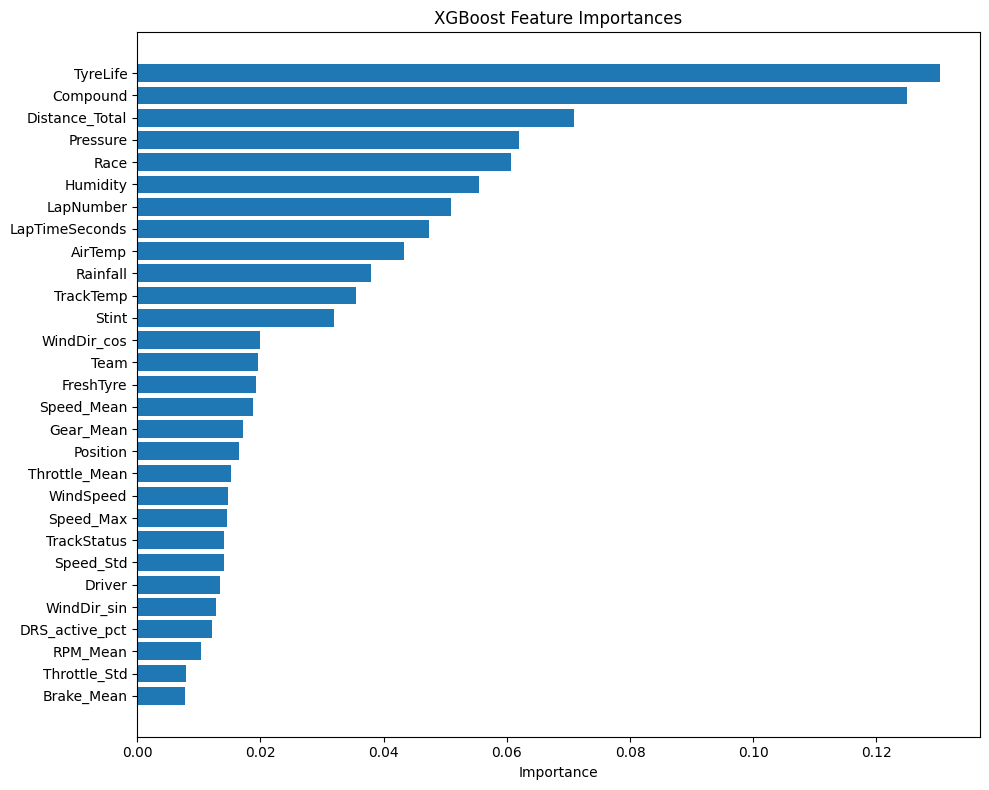

In [24]:
# Get feature importances and sort them
importances = xgb_reg.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices], importances[indices])
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Tune regression model

In [25]:
# Set up parameter grid
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0]
}

In [26]:
# Set up RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist,
    n_iter=50,  # number of parameter settings sampled
    scoring='neg_root_mean_squared_error',  # for RMSE
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)

# Fit on data
search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/opt/anaconda3/envs/nlp/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 500],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0.5, 1.0, 2.0],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=111, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [27]:
best_xgb = search.best_estimator_

print("Best parameters:", search.best_params_)

# Evaluate on validation and test
y_val_pred_tuned = best_xgb.predict(X_val)
y_test_pred_tuned = best_xgb.predict(X_test)

print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred_tuned):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred_tuned):.3f}")

Best parameters: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Validation Results:
RMSE: 8.923
MAE:  6.450
R2:   0.363

Test Results:
RMSE: 8.751
MAE:  6.479
R2:   0.293


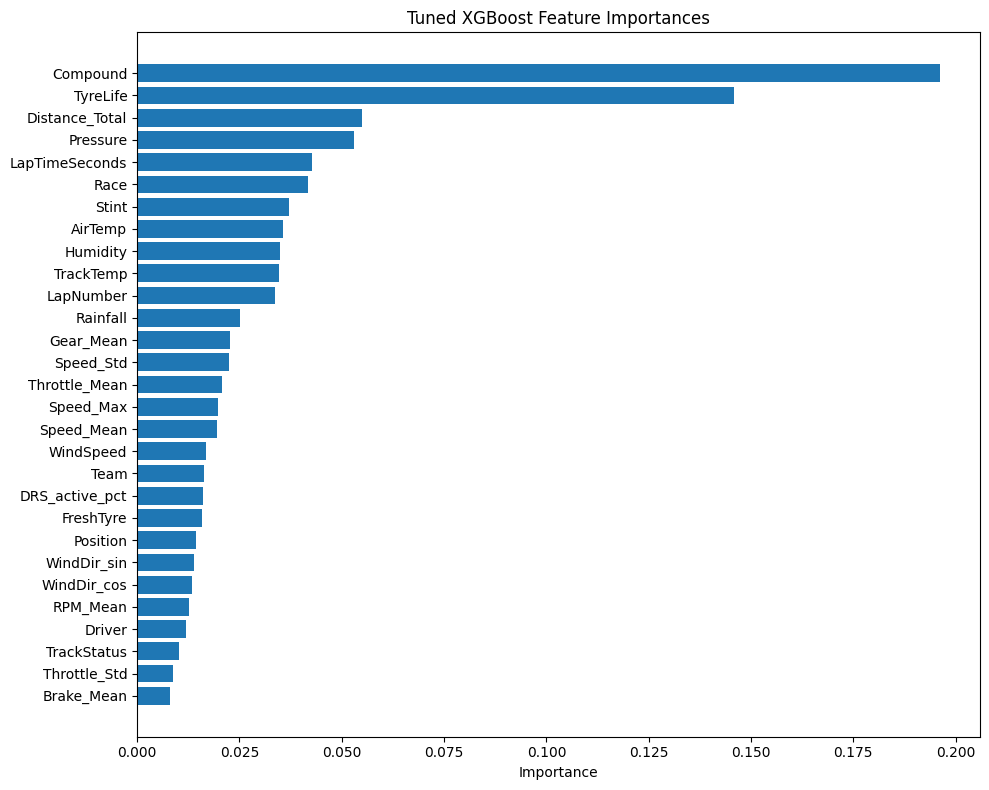

In [28]:
# Get feature importances and sort them
importances_tuned = best_xgb.feature_importances_
indices_tuned = np.argsort(importances_tuned)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices_tuned], importances_tuned[indices_tuned])
plt.title("Tuned XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Result: Poor generalization<br>
Pivot to classification problem, trying to predict whether pit in 5 laps.

#### Reframe as classification task

In [29]:
df_encoded_copy = df_encoded.copy()

In [30]:
# Binary label: 1 if pitting in next 5 laps (including this lap), else 0
df_encoded_copy['PitNext5'] = (df_encoded_copy['LapsTilPit'] <= 5).astype(int)

In [31]:
df_encoded_copy['PitNext5'].value_counts()

PitNext5
0    62811
1    19390
Name: count, dtype: int64

In [32]:
# Train, val, test split
train_df_cl = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
val_df_cl   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
test_df_cl  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [33]:
# Split sets into features and target
feature_cols = [col for col in train_df_cl.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# Training set
X_train_cl = train_df_cl[feature_cols]
y_train_cl = train_df_cl['PitNext5']

# Validation set
X_val_cl = val_df_cl[feature_cols]
y_val_cl = val_df_cl['PitNext5']

# Test set
X_test_cl = test_df_cl[feature_cols]
y_test_cl = test_df_cl['PitNext5']

In [34]:
print(X_train_cl.shape)
print(y_train_cl.shape)
print(X_val_cl.shape)
print(y_val_cl.shape)
print(X_test_cl.shape)
print(y_test_cl.shape)

(47033, 29)
(47033,)
(26381, 29)
(26381,)
(8787, 29)
(8787,)


#### Train XGBoost classifier model

In [35]:
# Train
xgb_base_cl = XGBClassifier()
xgb_base_cl.fit(X_train_cl, y_train_cl)

# Predict
y_val_pred_cl = xgb_base_cl.predict(X_val_cl)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val_cl, y_val_pred_cl))
print(classification_report(y_val_cl, y_val_pred_cl))

XGBoost Classifier Validation Set Performance:

[[17176  3266]
 [ 2222  3717]]
              precision    recall  f1-score   support

           0       0.89      0.84      0.86     20442
           1       0.53      0.63      0.58      5939

    accuracy                           0.79     26381
   macro avg       0.71      0.73      0.72     26381
weighted avg       0.81      0.79      0.80     26381



#### Tune classifier model

In [36]:
# Class imbalance -> calculate ratio of negative to positive class
ratio = (y_train_cl == 0).sum() / (y_train_cl == 1).sum()
ratio

np.float64(3.123169983343561)

In [37]:
param_grid_cl = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    # 'scale_pos_weight': [ratio, ratio*0.6, ratio*1.4],
}

In [38]:
search_cl = RandomizedSearchCV(
    xgb_base_cl,
    param_distributions=param_grid_cl,
    n_iter=60,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=4
)
search_cl.fit(X_train_cl, y_train_cl)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=60, n_jobs=4,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.1],
                                        'max_depth': [4, 6, 8],
                                        'n_estimators': [100, 200, 400],
                                        'subsample': [0.8, 1.0]},
                   random_state=111, scoring='f1_weighted', verbose=1)

In [39]:
best_xgb_cl = search_cl.best_estimator_
y_val_pred_cl_best = best_xgb_cl.predict(X_val_cl)

print(search_cl.best_params_)
print(confusion_matrix(y_val_cl, y_val_pred_cl_best))
print(classification_report(y_val_cl, y_val_pred_cl_best))

{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
[[18930  1512]
 [ 3469  2470]]
              precision    recall  f1-score   support

           0       0.85      0.93      0.88     20442
           1       0.62      0.42      0.50      5939

    accuracy                           0.81     26381
   macro avg       0.73      0.67      0.69     26381
weighted avg       0.79      0.81      0.80     26381



#### Create more bins

In [40]:
def pit_bin(laps_til_pit):
    if laps_til_pit <= 5:
        return 0
    elif laps_til_pit <= 10:
        return 1
    elif laps_til_pit <= 15:
        return 2
    else:
        return 3

df_encoded_copy['PitBins'] = df_encoded_copy['LapsTilPit'].apply(pit_bin)

In [41]:
print(df_encoded_copy['PitBins'].value_counts().sort_index())

PitBins
0    19390
1    17899
2    15075
3    29837
Name: count, dtype: int64


In [42]:
# Train, val, test split
train_df_bins = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
val_df_bins   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
test_df_bins  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [43]:
# Split sets into features and target
feature_cols = [col for col in train_df_bins.columns if col not in ['LapsTilPit', 'Year', 'PitNext5', 'PitBins']]

# Training set
X_train_bins = train_df_bins[feature_cols]
y_train_bins = train_df_bins['PitBins']

# Validation set
X_val_bins = val_df_bins[feature_cols]
y_val_bins = val_df_bins['PitBins']

# Test set
X_test_bins = test_df_bins[feature_cols]
y_test_bins = test_df_bins['PitBins']

#### Train XGB multiclass model

In [44]:
# Train
xgb_multi = XGBClassifier(num_class=4)
xgb_multi.fit(X_train_bins, y_train_bins)

# Predict
y_val_pred_bins = xgb_multi.predict(X_val_bins)

# Evaluate
print("XGBoost Multiclass Validation Set Performance:\n")
print(confusion_matrix(y_val_bins, y_val_pred_bins))
print(classification_report(y_val_bins, y_val_pred_bins))

XGBoost Multiclass Validation Set Performance:

[[4375  685  197  682]
 [2040 2069  391  985]
 [1366  808 1133 1351]
 [1376 1006  788 7129]]
              precision    recall  f1-score   support

           0       0.48      0.74      0.58      5939
           1       0.45      0.38      0.41      5485
           2       0.45      0.24      0.32      4658
           3       0.70      0.69      0.70     10299

    accuracy                           0.56     26381
   macro avg       0.52      0.51      0.50     26381
weighted avg       0.56      0.56      0.54     26381



In [45]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [46]:
search_mc = RandomizedSearchCV(
    estimator=xgb_multi,
    param_distributions=param_grid,
    n_iter=60,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=111
)
search_mc.fit(X_train_bins, y_train_bins)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_class=4, ...),
                   n_iter=60, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.9, 1.0]},
                   random_state=111, scoring='f1_macro', verbose=1)

In [47]:
best_xgb_multi = search_mc.best_estimator_
y_val_pred_best = best_xgb_multi.predict(X_val_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_val_bins, y_val_pred_best))
print(classification_report(y_val_bins, y_val_pred_best))

Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
[[3951  737  190 1061]
 [1629 2073  301 1482]
 [1220  583  974 1881]
 [1318  754  417 7810]]
              precision    recall  f1-score   support

           0       0.49      0.67      0.56      5939
           1       0.50      0.38      0.43      5485
           2       0.52      0.21      0.30      4658
           3       0.64      0.76      0.69     10299

    accuracy                           0.56     26381
   macro avg       0.54      0.50      0.50     26381
weighted avg       0.55      0.56      0.54     26381



In [48]:
y_test_pred_best = best_xgb_multi.predict(X_test_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_test_bins, y_test_pred_best))
print(classification_report(y_test_bins, y_test_pred_best))

Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
[[1388  247   49  360]
 [ 730  584   87  533]
 [ 538  286  185  588]
 [ 541  223  244 2204]]
              precision    recall  f1-score   support

           0       0.43      0.68      0.53      2044
           1       0.44      0.30      0.36      1934
           2       0.33      0.12      0.17      1597
           3       0.60      0.69      0.64      3212

    accuracy                           0.50      8787
   macro avg       0.45      0.45      0.42      8787
weighted avg       0.48      0.50      0.47      8787



#### Exploring model results


--- WEIGHT ---


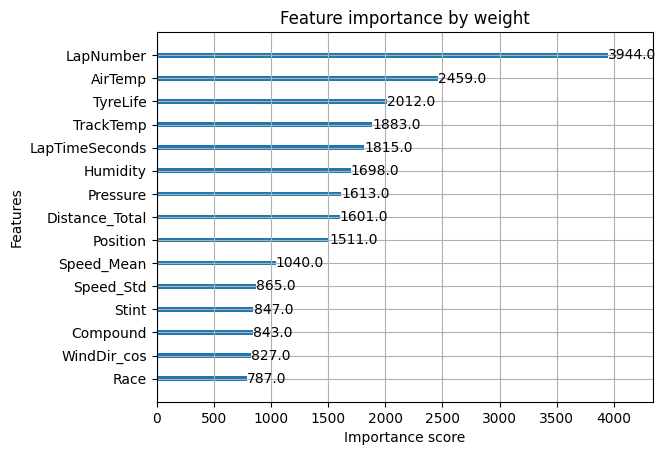


--- GAIN ---


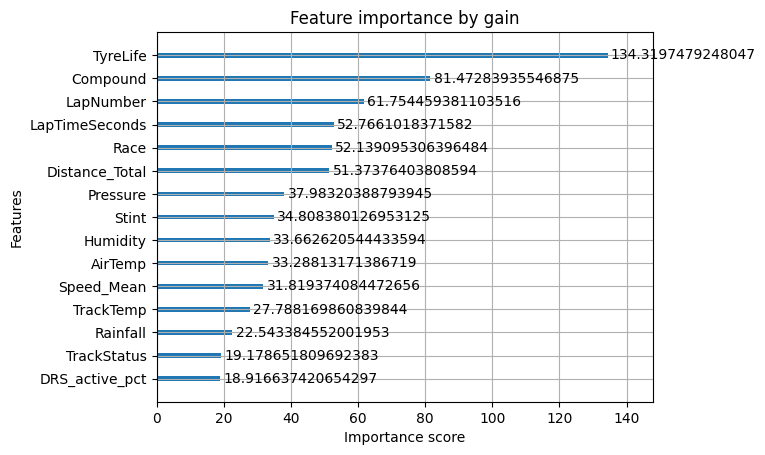


--- COVER ---


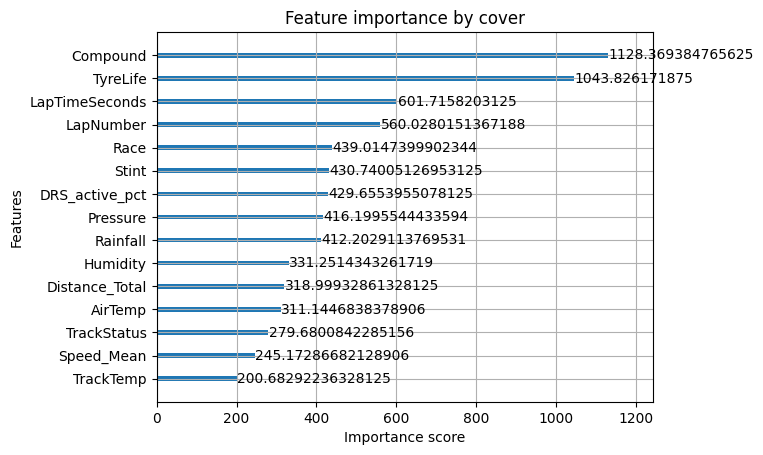

In [49]:
from xgboost import plot_importance

for t in ['weight', 'gain', 'cover']:
    print(f"\n--- {t.upper()} ---")
    plot_importance(best_xgb_cl, importance_type=t, max_num_features=15)
    plt.title(f"Feature importance by {t}")
    plt.show()

Find false positive/negative laps:

In [50]:
# Add predictions and true labels back to validation set
val_results = X_val_cl.copy()
val_results['TrueLabel'] = y_val_cl.values  # true pit/npit
val_results['PredLabel'] = y_val_pred_cl_best
val_results['Correct'] = (val_results['TrueLabel'] == val_results['PredLabel'])

In [51]:
# Reverse categorical encoding
for col in categorical_cols:
    val_results[col] = encoders[col].inverse_transform(val_results[col])

In [52]:
# Reverse standardization
val_results[numerical_cols] = scaler.inverse_transform(val_results[numerical_cols])

In [53]:
# Add LapsTilPit back in
val_results['LapsTilPit'] = y_val

In [54]:
val_results.shape

(26381, 33)

In [55]:
val_results.iloc[600]

Driver                           SAI
Team                         Ferrari
Race              Bahrain Grand Prix
Stint                            2.0
LapNumber                       31.0
Position                         3.0
Compound                        HARD
TyreLife                        17.0
FreshTyre                          1
TrackStatus                        1
AirTemp                         18.0
Humidity                        49.0
Pressure                      1017.3
Rainfall                           0
TrackTemp                       22.6
WindSpeed                        0.8
Speed_Mean                199.893557
Speed_Max                      303.0
Speed_Std                  68.559208
RPM_Mean                10056.714286
Throttle_Mean              67.607843
Throttle_Std               41.866464
Brake_Mean                   0.22409
Gear_Mean                   5.221289
Distance_Total           5376.746111
DRS_active_pct                   0.0
WindDir_sin                 0.994522
W

In [56]:
# False Positives: Predicted 1 (pit soon), actually 0 (not pitting soon)
false_positives = val_results[(val_results['PredLabel'] == 1) & (val_results['TrueLabel'] == 0)]

# False Negatives: Predicted 0, actually 1
false_negatives = val_results[(val_results['PredLabel'] == 0) & (val_results['TrueLabel'] == 1)]

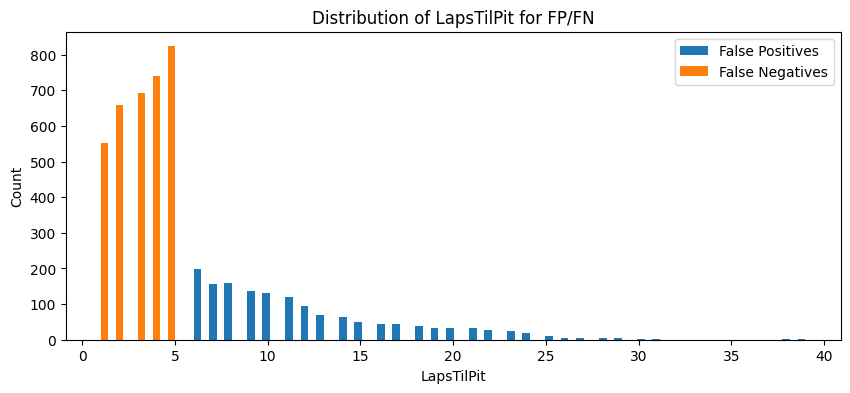

In [58]:
plt.figure(figsize=(10,4))
plt.hist(false_positives['LapsTilPit'], bins=80, label='False Positives')
plt.hist(false_negatives['LapsTilPit'], bins=10, label='False Negatives')
plt.xlabel('LapsTilPit')
plt.ylabel('Count')
plt.legend()
plt.title('Distribution of LapsTilPit for FP/FN')
plt.show()

In [60]:
# Mean TyreLife for FP/FN
print("False Positives: Mean TyreLife", false_positives['TyreLife'].mean())
print("False Negatives: Mean TyreLife", false_negatives['TyreLife'].mean())

False Positives: Mean TyreLife 23.24669312169312
False Negatives: Mean TyreLife 16.714615162871144


In [83]:
print('Stint Precision')
print(val_results.groupby('Stint')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Stint').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Stint').size())

Stint Precision
Stint
1.0    0.723270
2.0    0.857723
3.0    0.844920
4.0    0.838162
5.0    0.811024
Name: Correct, dtype: float64

False Positives
Stint
1.0    993
2.0    248
3.0    245
4.0      9
5.0     17
dtype: int64

False Negatives
Stint
1.0    1326
2.0    1363
3.0     596
4.0     153
5.0      31
dtype: int64


In [82]:
print('Compound Precision')
print(val_results.groupby('Compound')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Compound').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Compound').size())

Compound Precision
Compound
HARD            0.873729
INTERMEDIATE    0.579561
MEDIUM          0.778320
SOFT            0.781123
WET             0.281250
Name: Correct, dtype: float64

False Positives
Compound
HARD            150
INTERMEDIATE    626
MEDIUM          705
SOFT             31
dtype: int64

False Negatives
Compound
HARD            1576
INTERMEDIATE     275
MEDIUM          1248
SOFT             347
WET               23
dtype: int64


In [81]:
print('Rainfall Precision')
print(val_results.groupby('Rainfall')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Rainfall').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Rainfall').size())

Rainfall Precision
Rainfall
0    0.823117
1    0.617992
Name: Correct, dtype: float64

False Positives
Rainfall
0    1188
1     324
dtype: int64

False Negatives
Rainfall
0    3207
1     262
dtype: int64


In [97]:
print('TrackStatus Precision')
print(val_results.groupby('TrackStatus')['Correct'].agg(['count', 'mean']))

TrackStatus Precision
             count      mean
TrackStatus                 
1            24560  0.813477
12             619  0.799677
124            113  0.849558
125             18  0.333333
1254            16  0.062500
126             52  0.730769
1264            15  0.866667
1267             9  0.888889
14              34  0.323529
16              17  0.705882
167             22  0.772727
21              58  0.827586
24              44  0.681818
26              36  0.527778
267              1  0.000000
2671             2  0.500000
4              471  0.845011
41             161  0.944099
412             19  0.789474
6               26  0.538462
64              19  0.263158
671             58  0.637931
71              11  0.454545


In [105]:
precision_col = 'Rainfall'

print(f'{precision_col} Precision')
print(val_results.groupby(precision_col)['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby(precision_col).size())
print('\nFalse Negatives')
print(false_negatives.groupby(precision_col).size())

Rainfall Precision
Rainfall
0    0.823117
1    0.617992
Name: Correct, dtype: float64

False Positives
Rainfall
0    1188
1     324
dtype: int64

False Negatives
Rainfall
0    3207
1     262
dtype: int64


In [108]:
# filter out wet tires and try again